In [165]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import sys
from tqdm.auto import tqdm
import torch
import torch.nn as nn

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.3
pandas 3.0.1
sklearn 1.8.0
torch 2.10.0+cu128
cuda:0


# 数据准备

看灰度图片

In [166]:
from torchvision import datasets
from torchvision import transforms


# fashion_mnist图像分类数据集, 60000张训练图片, 10000张测试图片
train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=None
)

test_ds = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=None
)
# 划分训练集测试集, 只是看看图片, 先不转换

In [167]:
type(train_ds)

torchvision.datasets.mnist.FashionMNIST

In [168]:
len(test_ds)

10000

In [169]:
type(train_ds[0])

tuple

In [170]:
img, lab = train_ds[0]
# 通过id取数据，取到的是一个元祖,是第一个样本
lab

9

In [171]:
print(type(img))
img

<class 'PIL.Image.Image'>


In [172]:
def show_img_content(image):
    print("图像大小:", image.size)
    print("图像模式:", image.mode)


    # 如果图像是单通道的，比如灰度图，你可以这样获取像素值列表：
    if image.mode == 'L':
        pixel_values = np.array(image)
        print(pixel_values)
show_img_content(img) 

图像大小: (28, 28)
图像模式: L
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1

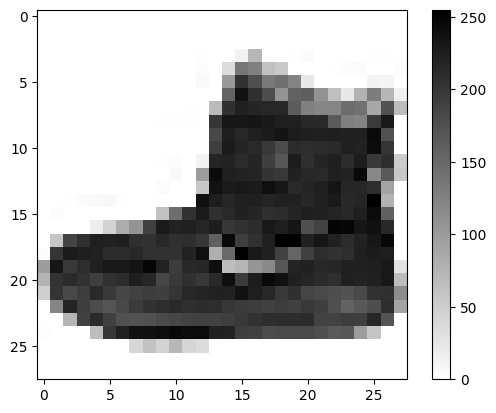

In [173]:
def show_single_image(img_arr):
    plt.imshow(img_arr, cmap="binary") # 显示图片
    plt.colorbar() # 显示颜色条
    plt.show()


show_single_image(img)

数据预处理, 为训练准备

In [193]:

# 定义数据集的变换
transform = transforms.Compose([
    transforms.ToTensor(),
    # 转换成Tensor, 并归一化
    # transforms.Normalize(mean, std)
])
train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

In [194]:
img_tensor, lab = train_ds[0]
print(img_tensor.shape)
# 返回图片张量, 对应的标签
# 1是通道数, 宽高各28
print(type(img_tensor))
lab

torch.Size([1, 28, 28])
<class 'torch.Tensor'>


9

In [195]:
#计算均值和方差
def cal_mean_std(ds):
    mean = 0.
    std = 0.
    for image_input, _ in ds:  
        # 遍历每张图片, image.shape=[1,28,28]
        mean += image_input.mean(dim=(1, 2))  
        # 计算每张图片的均值, dim=(1, 2)表示每张图片的宽高共同求均值
        std += image_input.std(dim=(1, 2))
    mean /= len(ds)
    std /= len(ds)
    return mean, std
    # 单通道的图, mean结果是0维张量 
    # 如果是多通道的图, mean是1维张量, 传入Normalize时最好使用tolist

mean_train, std_train = cal_mean_std(train_ds)
print(cal_mean_std(train_ds))

(tensor([0.2860]), tensor([0.3205]))


In [196]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_train, std_train)
])
# 重新定义变换, 加上标准化
train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_ds = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

In [197]:
lab
# 标签是0到9

9

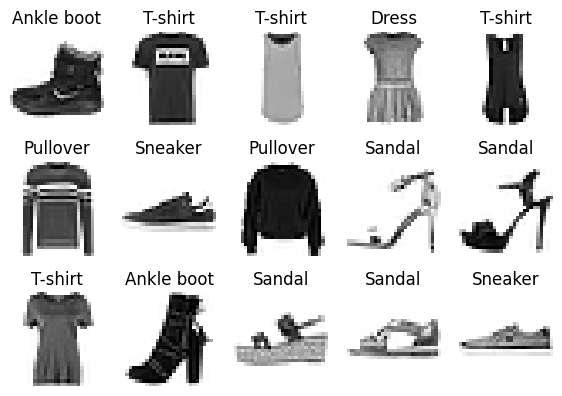

In [198]:
def show_imgs(n_rows, n_cols, train_dataset, class_name):
    assert n_rows * n_cols < len(train_dataset)  # 确保打印的图片小于总样本数
    plt.figure(figsize = (n_cols * 1.4, n_rows * 1.6))  
    # 画布宽1.4宽1.6
    for row in range(n_rows):
        for col in range(n_cols):
            index = n_cols * row + col  # 计算索引，从0开始
            plt.subplot(n_rows, n_cols, index+1)#因为从1开始
            img_arr, label = train_dataset[index]
            img_arr = np.transpose(img_arr, (1, 2, 0))  
            # 画图时将通道换到最后一维
            plt.imshow(img_arr, cmap="binary", interpolation = 'nearest')
            # interpolation='nearest' 是临近插值
            plt.axis('off')
            # 去除坐标系
            plt.title(class_name[label]) 
            # 显示类别名称
    plt.show()
    
    
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress',
               'Coat', 'Sandal', 'Shirt', 'Sneaker',
               'Bag', 'Ankle boot'] 
#0-9分别代表的类别
show_imgs(3, 5, train_ds, class_names)
# 打印前15个样本

In [199]:
# 数据加载器, 将其进行分批和其他处理
train_ld = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)  
#batch_size批大小，shuffle洗牌
val_ld = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False)
# 验证集不需要打乱

在PyTorch中，DataLoader是一个迭代器，它封装了数据的加载和预处理过程，使得在训练机器学习模型时可以方便地批量加载数据。DataLoader主要负责以下几个方面：  
1. 批量加载数据：DataLoader可以将数据集（Dataset）切分为更小的批次（batch），每次迭代提供一小批量数据，而不是单个数据点。这有助于模型学习数据中的统计依赖性，并且可以更高效地利用GPU等硬件的并行计算能力。  
2. 数据打乱：默认情况下，DataLoader会在每个epoch（训练周期）开始时打乱数据的顺序。这有助于模型训练时避免陷入局部最优解，并且可以提高模型的泛化能力。  
3. 多线程数据加载：DataLoader支持多线程（通过参数num_workers）来并行地加载数据，这可以显著减少训练过程中的等待时间，尤其是在处理大规模数据集时。  
4. 数据预处理：DataLoader可以与transforms结合使用，对加载的数据进行预处理，如归一化、标准化、数据增强等操作。  
5. 内存管理：DataLoader负责管理数据的内存使用，确保在训练过程中不会耗尽内存资源。  
6. 易用性：DataLoader提供了一个简单的接口，可以很容易地集成到训练循环中。

In [200]:
for datas, labels in train_ld:
    print(datas[0])
    print(labels)
    # 十类标签, 批次大小为32
    break
for datas, labels in val_ld:
    print(datas.shape)
    print(labels.shape)
    break
    # tensor是四维的(batch_size, channels, height, width)

tensor([[[-0.8926, -0.8926, -0.8926, -0.8926, -0.8926, -0.8926, -0.8926,
          -0.8926, -0.8804, -0.8926, -0.8926, -0.0849,  0.4780,  0.7839,
           0.8084,  0.6004,  0.5881,  0.7472, -0.4031, -0.8926, -0.8926,
          -0.8926, -0.8926, -0.8926, -0.8926, -0.8926, -0.8926, -0.8926],
         [-0.8926, -0.8926, -0.8926, -0.8926, -0.8926, -0.8926, -0.8926,
          -0.8926, -0.8926, -0.8926,  1.5549,  2.0689,  1.8608,  1.8975,
           2.1545,  2.1912,  1.8364,  1.8731,  1.9710, -0.3297, -0.8926,
          -0.8437, -0.8926, -0.8926, -0.8926, -0.8926, -0.8926, -0.8926],
         [-0.8926, -0.8926, -0.8926, -0.8926, -0.8926, -0.8926, -0.8926,
          -0.8926, -0.8926, -0.8926,  1.5427,  1.8608,  1.6038,  1.6528,
           1.6406,  1.6895,  1.6650,  1.6406,  2.0566,  0.7350, -0.8926,
          -0.8437, -0.8926, -0.8926, -0.8926, -0.8926, -0.8926, -0.8926],
         [-0.8926, -0.8926, -0.8926, -0.8926, -0.8926, -0.8926, -0.8926,
          -0.8926, -0.8926, -0.8926,  0.8818,  1

# 定义模型

In [201]:
class NeuralNetwork(nn.Module):
    # 继承nn.Module
    def __init__(self):
        super().__init__() 
        # 继承父类的初始化方法，子类有父类的属性
        self.flatten = nn.Flatten()  
        # 展平层, 将784个像素变成784个特征
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(784, 300),  
            # 全连接层/线性层
            # in_features=784输入特征数, out_features=300输出特征数
            nn.ReLU(), 
            # 激活函数
            nn.Linear(300, 100),
            # 隐藏层神经元数100
            nn.ReLU(), 
            # 激活函数
            nn.Linear(100, 10),
            # 输出层神经元数10, 对应十个标签
        )

    def forward(self, x): 
        # 重写父类的forward, 进行正向计算/前向传播
        # 展平前x.shape是[32, 1, 28, 28]
        x = self.flatten(x)
        # 展平后x.shape是[32, 784]
        logits = self.linear_relu_stack(x)
        # linear_relu_stack使用了Sequential这一封装容器, 自动顺序执行每层计算
        # logits.shape是[32, 10]
        return logits 
        # 没有经过softmax处理的输出, 称为logits
    
network = NeuralNetwork()

In [202]:
network
# 父类nn.Module已经写好了__str__方法, 显示模型结构

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=300, bias=True)
    (1): ReLU()
    (2): Linear(in_features=300, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=10, bias=True)
  )
)

In [203]:
image_random = torch.randn(32, 1, 28, 28)
print(image_random.shape)
image_logits = network(image_random)
# nn.Module在被调用时会自动调用__call__, 然后执行forward
# 验证模型输入输出是否符合预期
print(image_logits.shape)

torch.Size([32, 1, 28, 28])
torch.Size([32, 10])


In [204]:
for name, param in network.named_parameters(): 
    # 打印模型参数
    print(name)
    print(param.shape)

linear_relu_stack.0.weight
torch.Size([300, 784])
linear_relu_stack.0.bias
torch.Size([300])
linear_relu_stack.2.weight
torch.Size([100, 300])
linear_relu_stack.2.bias
torch.Size([100])
linear_relu_stack.4.weight
torch.Size([10, 100])
linear_relu_stack.4.bias
torch.Size([10])


权重矩阵形状 [300, 784] 表示：
每一行对应一个输出神经元的权重（总共 300 个神经元）, 每一列对应输入的一个特征（784 个像素）   
全连接层公式y=xW+b, 但是这里的W和存储方式是转置的, 即存储的是W^T  
这是为了
1. C/C++底层用行优先存储效率更高
2. 每行对应一个输出神经元，更直观
3. 梯度计算自然

偏置向量 [300] , 在输出的每一列上加上一个偏置

In [205]:
print(784*300+300+100*300+100+100*10+10)
total = sum(p.numel() for p in network.parameters())
# numel() 是返回张量元素个数, 累加每层的数量得到总参数量
print(f'Total number of parameters: {total:,}')

266610
Total number of parameters: 266,610


# 训练
1. 定义损失函数
2. 定义优化器
3. 定义训练步
4. 训练

In [206]:
# 1. 定义损失函数
loss_fct = nn.CrossEntropyLoss()
# 输出时将logits经过softmax, 和转换为one-hot编码的标签值计算交叉熵损失
# 得到的是标量(0维张量)

# 2. 定义优化器 采用SGD(随机梯度下降, stochastic gradient descent)
opt = torch.optim.SGD(network.parameters(), lr=0.001, momentum=0.9)
# lr学习率, momentum动量

In [207]:
from sklearn.metrics import accuracy_score

# 3.编写评估函数
@torch.no_grad() 
# 装饰器，禁止反向传播，节省内存
def evaluating(model, dataloader, loss_function):
    loss_list = [] 
    # 记录损失
    pred_list = [] 
    # 记录预测
    label_list = [] 
    # 记录标签
    for data, label in dataloader:
        # 一共10000/32=312个batch
        data = data.to(device) 
        # 把tensor放入GPU
        label = label.to(device) 
        # 转到GPU
        logits = model(data)
        # 前向计算
        loss = loss_function(logits, label)        
        # 使用loss_function计算本batch的损失, 得到的实际上是一个张量
        loss_list.append(loss.item()) 
        # 记录损失, item把tensor转换为数值, 注意item只能处理0维张量  
        
        pred = logits.argmax(axis=-1)    
        # 验证集预测, argmax返回最大值索引数组
        # logits是一个(32, 10)数组, 求出的pred是一个(32, )数组,
        # 即每个样本使用十个标签概率的最大值的索引作为预测值
        pred_list.extend(pred.cpu().numpy().tolist())
        # numpy()将PyTorch张量转换为NumPy数组。只有当张量在CPU上时，这个转换才是合法的
        label_list.extend(label.cpu().numpy().tolist())
        
    acc = accuracy_score(label_list, pred_list) 
    # 计算准确率
    return np.mean(loss_list), acc

In [208]:
# 4.训练

def training(model, train_loader, val_loader, epoch, loss_function,
             optimizer, eval_step=1000):
    """
    训练函数
    :param model: 模型
    :param train_loader: 训练数据集
    :param val_loader: 验证数据集
    :param epoch: 训练轮数
    :param loss_function: 损失函数
    :param optimizer: 优化器
    :param eval_step: 每训练多少batch对验证集进行评估
    :return: dict
    """
    record_dict = {
        "train": [],
        "val": []
    }
    # 存储训练集和测试集的损失和准确率
    global_step = 0
    # 记录总步数, 在进度条中使用
    model.train()
    # 进入训练模式
    # 对于一些特定层很重要：
    # Dropout → 在训练阶段才会随机丢弃神经元
    # BatchNorm → 使用 batch 的均值和方差
    with tqdm(total=epoch * len(train_loader)) as pbar: 
        # with是上下文管理器, 保证进度条结束后自动关闭
        # 进度条一共 len(train_loader)*epoch 步
        for epoch_id in range(epoch): 
            # 训练epoch次
            for data, label in train_loader: 
                # 每次迭代得到一个batch
                # 执行次数是60000/32=1875
                data = data.to(device) 
                # datas尺寸是[batch_size,1,28,28], 转到GPU
                label = label.to(device) 
                # labels尺寸是[batch_size], 转到GPU
                optimizer.zero_grad()
                # 梯度清空, PyTorch会累加梯度, 要避免上一batch的梯度影响后面
                logits = model(data)
                # 正向计算, 得到未经过softmax的输出
                loss = loss_function(logits, label)
                # 计算损失
                loss.backward()
                # 梯度回传, loss.backward()会计算梯度, loss对模型参数(权重和偏置)求导
                optimizer.step()
                # 调整优化器，改变学习率(如果使用了学习率调度器), 更新模型参数和一些其他值
                # 梯度计算并存储在模型参数的 .grad 属性中
                # 优化器使用这些存储的梯度来更新模型参数

                pred = logits.argmax(axis=-1) 
                # 对训练集预测
                acc = accuracy_score(label.cpu().numpy(), pred.cpu().numpy()) 
                # 每个batch计算准确率
                loss = loss.cpu().item()
                # loss这一0维张量转换为数值
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                }) 
                # 记录训练集信息，每一步的损失，准确率，步数
                
                if global_step % eval_step == 0:
                    model.eval() 
                    # 进入评估模式
                    # Dropout 停用
                    # BatchNorm 使用训练时统计值
                    val_loss, val_acc = evaluating(model, val_loader, 
                                                   loss_function)
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train() 
                    # 进入训练模式

                global_step += 1 
                # 全局步数加1
                pbar.update(1) 
                # 更新进度条
                pbar.set_postfix({"epoch": epoch_id}) 
                # 设置进度条显示信息
        
    return record_dict
        

epoch_num = 20
network = network.to(device)
record = training(network, train_ld, val_ld, epoch_num, 
                  loss_fct, opt, eval_step=1000)

  0%|          | 0/37500 [00:00<?, ?it/s]

In [209]:
record["train"][-5:]

[{'loss': 0.35326462984085083, 'acc': 0.875, 'step': 37495},
 {'loss': 0.20466312766075134, 'acc': 0.9375, 'step': 37496},
 {'loss': 0.12361837923526764, 'acc': 0.9375, 'step': 37497},
 {'loss': 0.2661356031894684, 'acc': 0.96875, 'step': 37498},
 {'loss': 0.212177574634552, 'acc': 0.84375, 'step': 37499}]

In [210]:
record["val"][-5:]

[{'loss': np.float64(0.3200204383058194), 'acc': 0.8857, 'step': 33000},
 {'loss': np.float64(0.330147792855962), 'acc': 0.8845, 'step': 34000},
 {'loss': np.float64(0.3241020432723978), 'acc': 0.8872, 'step': 35000},
 {'loss': np.float64(0.33443084807275014), 'acc': 0.8844, 'step': 36000},
 {'loss': np.float64(0.3240000369509283), 'acc': 0.8833, 'step': 37000}]

Index(['loss', 'acc'], dtype='str')
step
0        0.12500
1000     0.81250
2000     0.75000
3000     0.90625
4000     0.81250
5000     0.93750
6000     0.78125
7000     0.84375
8000     0.93750
9000     0.78125
10000    0.90625
11000    0.84375
12000    0.84375
13000    0.84375
14000    0.90625
15000    0.96875
16000    0.81250
17000    0.96875
18000    1.00000
19000    0.78125
20000    0.81250
21000    0.96875
22000    0.93750
23000    0.87500
24000    0.81250
25000    0.96875
26000    0.96875
27000    0.90625
28000    0.93750
29000    0.81250
30000    1.00000
31000    0.93750
32000    0.84375
33000    1.00000
34000    0.84375
35000    0.96875
36000    0.93750
37000    0.90625
Name: acc, dtype: float64
step
0        0.1151
1000     0.7948
2000     0.8224
3000     0.8335
4000     0.8442
5000     0.8494
6000     0.8556
7000     0.8568
8000     0.8522
9000     0.8634
10000    0.8664
11000    0.8703
12000    0.8676
13000    0.8711
14000    0.8748
15000    0.8745
16000    0.8708
17000    0

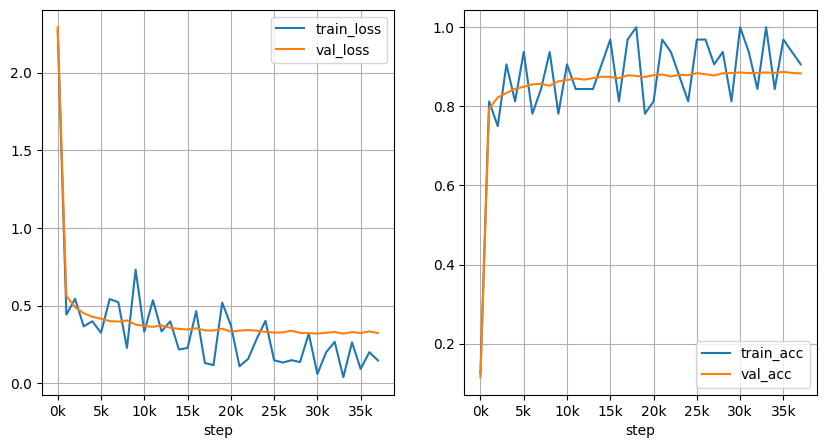

In [211]:
def plot_learning_curves(record_dict, sample_step=1000):
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    # set_index将行索引设置成step, 每隔sample_step取一次
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")
    last_step = train_df.index[-1]
    # 最后一步的步数
    print(train_df.columns)
    print(train_df['acc'])
    print(val_df['acc'])
    
    fig_num = len(train_df.columns)
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for idx, item in enumerate(train_df.columns):
        # enumerate同时得到索引和值
        # print(train_df[item].values)
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")
        axs[idx].grid()
        axs[idx].legend()
        axs[idx].set_xticks(range(0, train_df.index[-1], 5000)) 
        axs[idx].set_xticklabels(map(lambda x: f"{int(x/1000)}k", range(0, last_step, 5000)))
        axs[idx].set_xlabel("step")
    
    plt.show()

plot_learning_curves(record)